[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sibbirhossain/finguard-xai/blob/main/notebooks/05_realtime_performance.ipynb)

# 05 · Real-Time Performance

**Question:** *is graph AI fast enough to score a payment while it is being authorized?*

Card authorization decisions are typically expected within a small fraction of a second end to end. This notebook measures FinGuard-XAI's per-transaction scoring on a single CPU thread: graph update, 2-hop subgraph extraction, GNN, Deep SVDD, and fusion.

In [1]:
# --- Setup: works in Google Colab and inside a local clone ---
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")
if os.path.exists("../src/models"):
    os.chdir("..")
elif not os.path.exists("src/models"):
    if not os.path.exists("finguard-xai"):
        subprocess.run(["git", "clone", "-q", "https://github.com/sibbirhossain/finguard-xai.git"], check=True)
    os.chdir("finguard-xai")
try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"], check=True)
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("ready:", os.getcwd())

ready: /home/claude/finguard-xai


In [2]:
from pathlib import Path
from src.models.train import main as train_main
ART = "artifacts/notebook"
if not Path(ART, "model.pt").exists():   # train a compact model (~1-2 min on CPU)
    train_main(["--n-normal", "10000", "--epochs", "4", "--out", ART,
                "--report", "reports/notebook/RESULTS.md", "--bench-n", "100"])
from src.models.pipeline import FinGuardEngine
engine = FinGuardEngine.load(ART)
print("engine loaded · alert threshold", round(engine.scorer.threshold, 3))

engine loaded · alert threshold 0.479


In [3]:
import torch; torch.set_num_threads(1)
from src.api.stream_simulator import generate_transactions
from src.models.graph_engine import Transaction
stream = generate_transactions(n_normal=15000, n_rings=15, n_ato=75, seed=321)
split = int(0.7 * len(stream))
for r in stream[:split]: engine.graph.add_transaction(Transaction.from_dict(r))
lat, expl = [], []
for r in stream[split:split + 2000]:
    out = engine.score(r, explain=len(expl) < 15)
    lat.append(out["latency_ms"]["scoring_total"])
    if out["latency_ms"]["explanation"] is not None: expl.append(out["latency_ms"]["explanation"])
p50, p95, p99 = np.percentile(lat, [50, 95, 99])
print(f"scored {len(lat)} transactions · p50 {p50:.2f} ms · p95 {p95:.2f} ms · p99 {p99:.2f} ms · ~{1000/np.mean(lat):.0f} txn/s per CPU thread")
print(f"GNNExplainer (alerts only, off the scoring path): median {np.median(expl):.0f} ms over {len(expl)} alerts")

scored 2000 transactions · p50 3.75 ms · p95 4.64 ms · p99 5.13 ms · ~264 txn/s per CPU thread
GNNExplainer (alerts only, off the scoring path): median 99 ms over 15 alerts


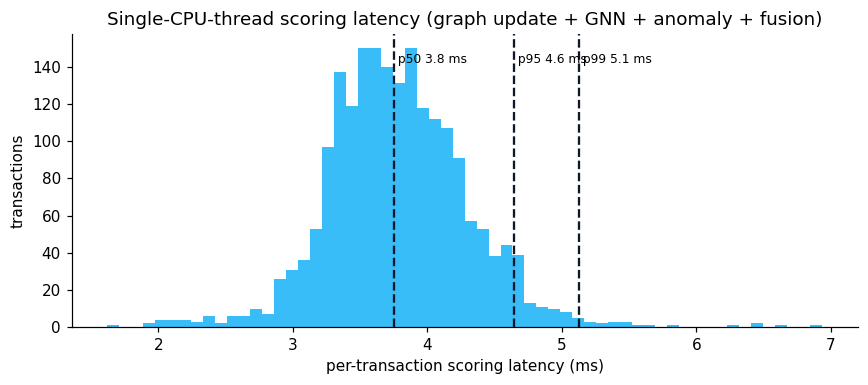

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(lat, bins=60, color="#38bdf8")
for v, name in ((p50, "p50"), (p95, "p95"), (p99, "p99")):
    ax.axvline(v, ls="--", color="#0f172a"); ax.text(v, ax.get_ylim()[1] * .9, f" {name} {v:.1f} ms", fontsize=8)
ax.set_xlabel("per-transaction scoring latency (ms)"); ax.set_ylabel("transactions")
ax.set_title("Single-CPU-thread scoring latency (graph update + GNN + anomaly + fusion)"); plt.tight_layout(); plt.show()

### Engineering choices that make this fast
- **Bounded neighborhoods.** Each entity keeps only its 64 most recent interactions, and inference samples 8 neighbors per hop. Cost per event stays flat as history grows.
- **Subgraph inference.** The GNN runs on the ~10–300-node neighborhood of *this* transaction, not the whole graph.
- **Explanations off the hot path.** They run on a separate model copy, and only for alerts.

*Measured on the hardware shown in the setup output. Production throughput would scale horizontally and depends on hardware and graph size.*